<a href="https://colab.research.google.com/github/peemoshi/ai-ml-internship/blob/main/week-1/1.2-data-cleaning-eda/eda_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
!wget -q {url} -O student.zip
!unzip -o -q student.zip

df = pd.read_csv("student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
print(df.shape)
print(df.columns.tolist())
df.info()

(395, 33)
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    obje

In [3]:
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\n", df.describe())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Duplicate rows: 0

               age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    

In [4]:
print("Students with G3 == 0:", (df['G3'] == 0).sum())
print("Students with G1 or G2 == 0 but G3 != 0:", ((df['G1'] == 0) | (df['G2'] == 0)) .sum())
print("\nAbsences over 20:\n", df[df['absences'] > 20][['absences', 'G1', 'G2', 'G3']])

Students with G3 == 0: 38
Students with G1 or G2 == 0 but G3 != 0: 13

Absences over 20:
      absences  G1  G2  G3
40         25   7  10  11
74         54  11  12  11
103        26   7   6   6
183        56   9   9   8
198        24  18  18  18
205        28  10   9   9
216        22   6   6   4
260        21  17  18  18
276        75  10   9   9
277        22   9   9   9
280        30   8   8   8
307        38   8   9   8
313        22  13  10  11
315        40  13  11  11
320        23  13  13  13


In [5]:
df['completed_exam'] = df['G3'] > 0

print("Completed exam:", df['completed_exam'].sum())
print("Did not complete:", (~df['completed_exam']).sum())

# Save the cleaned/annotated version separately, the raw file stays untouched
df.to_csv('student_mat_cleaned.csv', index=False)

Completed exam: 357
Did not complete: 38


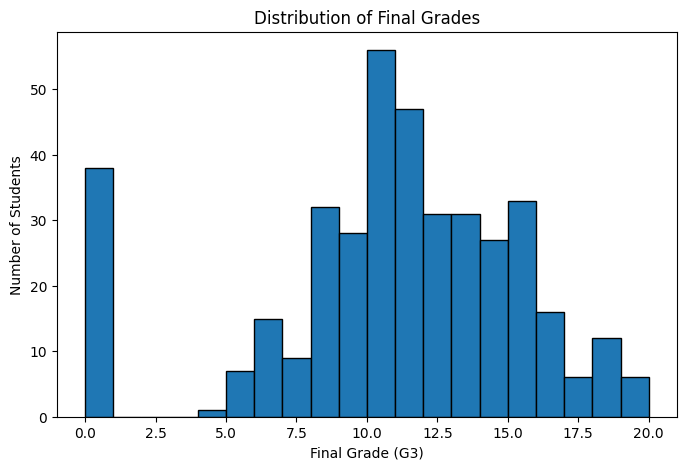

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['G3'], bins=20, edgecolor='black')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.title('Distribution of Final Grades')
plt.show()

**"G3 is roughly normally distributed around 11–15 (out of 20), with a secondary spike at 0. This spike doesn't represent students who failed, it's the 38 students who didn't complete the exam (completed_exam = False), which is a different phenomenon and shouldn't be read as 'low performance.'"**

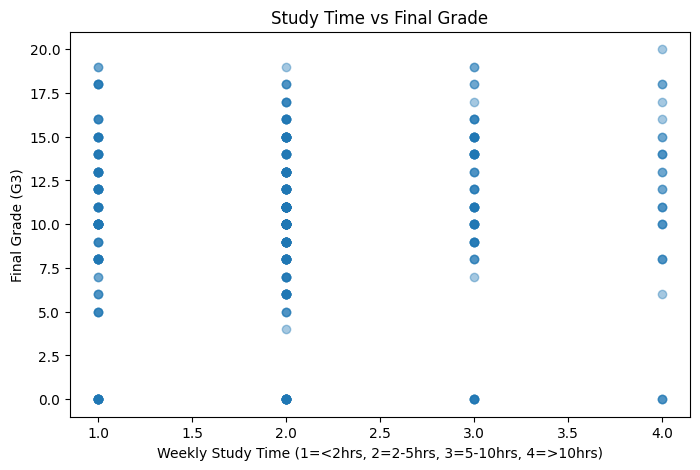

<Figure size 800x500 with 0 Axes>

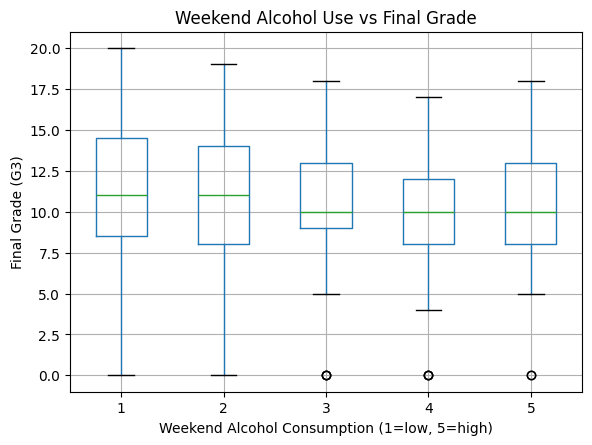

In [7]:
# Chart 2: Does studying more actually correlate with better grades?
plt.figure(figsize=(8,5))
plt.scatter(df['studytime'], df['G3'], alpha=0.4)
plt.xlabel('Weekly Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)')
plt.ylabel('Final Grade (G3)')
plt.title('Study Time vs Final Grade')
plt.show()

# Chart 3: Does alcohol consumption relate to grades?
plt.figure(figsize=(8,5))
df.boxplot(column='G3', by='Walc')
plt.xlabel('Weekend Alcohol Consumption (1=low, 5=high)')
plt.ylabel('Final Grade (G3)')
plt.title('Weekend Alcohol Use vs Final Grade')
plt.suptitle('')
plt.show()

**"Study time shows no to little grade improvement in this data, and heavier alcohol use is associated with only a ~1 point lower median grade. These are weak associations, not a proof that either variable causes the outcome, other factors such as family, motivation and background likely explain more of the variation."**

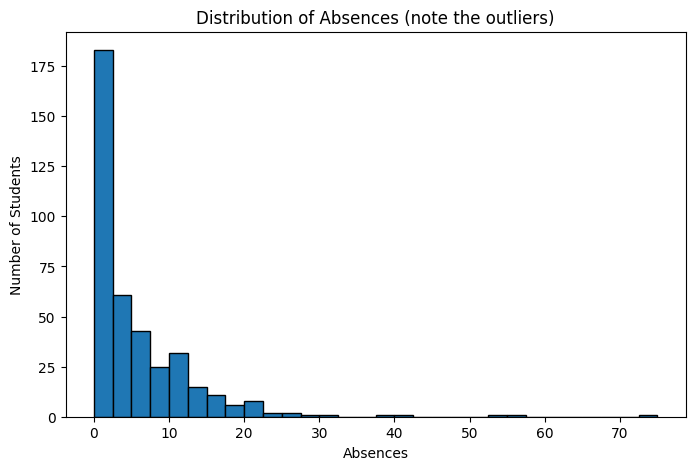

<Figure size 800x500 with 0 Axes>

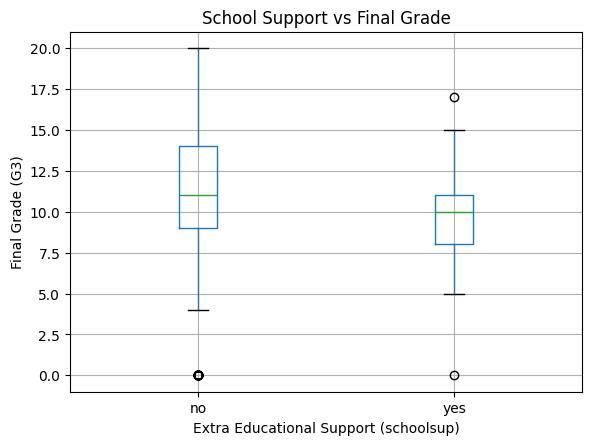

In [8]:
# Chart 4: absences distribution (shows the outliers directly)
plt.figure(figsize=(8,5))
plt.hist(df['absences'], bins=30, edgecolor='black')
plt.xlabel('Absences')
plt.ylabel('Number of Students')
plt.title('Distribution of Absences (note the outliers)')
plt.show()

# Chart 5: does extra school support relate to grades?
plt.figure(figsize=(8,5))
df.boxplot(column='G3', by='schoolsup')
plt.xlabel('Extra Educational Support (schoolsup)')
plt.ylabel('Final Grade (G3)')
plt.title('School Support vs Final Grade')
plt.suptitle('')
plt.show()

**"Students receiving extra school support (schoolsup) had a lower median grade than those who didn't. This is likely reversed causation where support is most likely assigned to students already at risk academically, rather than support causing worse outcomes."**

**Key Insights**


---


1.   No missing values/duplicates, but 38 students had G3=0 (didn't complete exam)  kept but flagged, since removing them would lose the data; while treating them as "failed" would be misleading
2.   Absences are heavily skewed, with a few extreme outliers (up to 75)
3.   Study time shows little relationship with final grade
4.   Alcohol use shows a small negative association
5.   School support shows a misleading negative association (likely reverse causation)


